# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [333]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

#### 1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).


In [334]:
df = pd.read_csv('../data/checker_submits.csv')

#### 2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.


In [335]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df.drop('timestamp', axis=1)

In [336]:
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


#### 3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.


In [337]:
encoder = OneHotEncoder()
columns_to_encode = ['uid', 'labname']

In [338]:
encoded_arr = encoder.fit_transform(df[columns_to_encode]).toarray()

In [339]:
encoded_arr

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]])

In [340]:
encoded_df = pd.DataFrame(encoded_arr, columns=encoder.get_feature_names_out(columns_to_encode), index=df.index)

In [341]:
encoded_df

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [342]:
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(columns=columns_to_encode)

In [343]:
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,9,20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,6,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,7,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,8,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


#### 4. Use `StandardScaler()` and scale your continuous features.


In [344]:
scaler = StandardScaler()
df[['numTrials', 'hour']] = scaler.fit_transform(df[['numTrials', 'hour']])

In [345]:
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


#### 5. Save the dataframe as `dayofweek.csv`.


In [346]:
df.to_csv('../data/dayofweek.csv', index=False)

#### 6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [347]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

In [348]:
pred = [y.mode()[0]] * len(y)

In [349]:
pred

[3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,


In [350]:
accuracy_score(y, pred)

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

#### 1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 


In [351]:
# multi_class='multinomial'
log_reg = LogisticRegression(random_state=21, fit_intercept=False)

In [352]:
log_reg.fit(X, y)

LogisticRegression(fit_intercept=False, random_state=21)

In [353]:
pred = log_reg.predict(X)

#### 2. Calculate the accuracy.


In [354]:
accuracy_score(y, pred)

0.6405693950177936

#### 3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.


In [355]:
def draw(coefs, features, n):
    coefs = coefs.mean(axis=0)
    coefs /= coefs.sum()
    indices = coefs.argsort()[::-1][:n]
    
    fig, ax = plt.subplots(figsize=(10,7))
    ax.barh(range(n), coefs[indices])
    ax.set_yticks(range(n))
    ax.set_yticklabels(features[indices])
    ax.invert_yaxis()

#### 4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
#### 5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.


In [356]:
coefs = log_reg.coef_

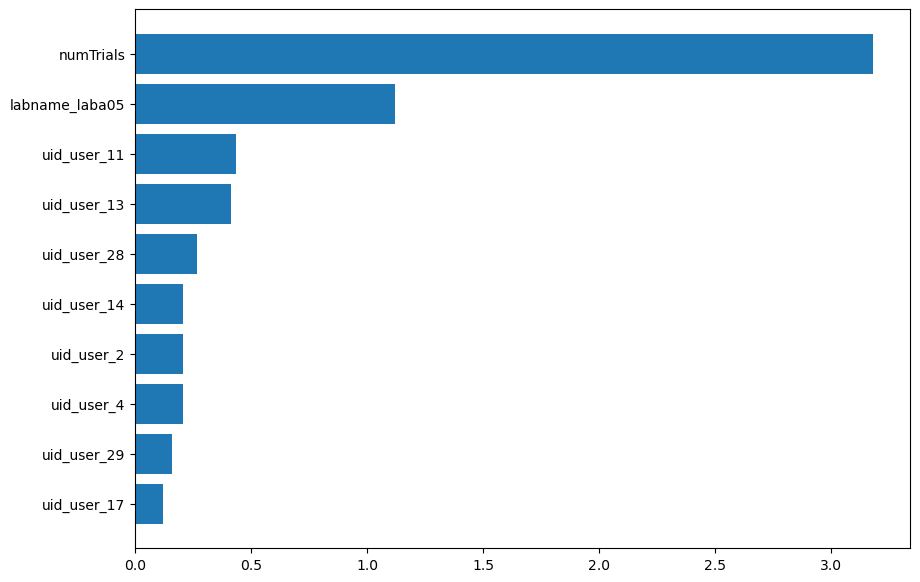

In [357]:
draw(coefs, X.columns, 10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

#### 1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 

In [358]:
svc = SVC(kernel='linear', probability=True, random_state=21)

In [359]:
svc.fit(X, y)

SVC(kernel='linear', probability=True, random_state=21)

In [360]:
pred = svc.predict(X)

In [361]:
accuracy_score(y, pred)

0.702846975088968

#### 2. Try different kernels, calculate the accuracies.


In [362]:
# linear
svc = SVC(kernel='linear', probability=True, random_state=21)
svc.fit(X, y)
pred = svc.predict(X)
accuracy_score(y, pred)

0.702846975088968

In [363]:
# poly
svc = SVC(kernel='poly', probability=True, random_state=21)
svc.fit(X, y)
pred = svc.predict(X)
accuracy_score(y, pred)

0.8594306049822064

In [364]:
# sigmoid
svc = SVC(kernel='sigmoid', probability=True, random_state=21)
svc.fit(X, y)
pred = svc.predict(X)
accuracy_score(y, pred)

0.3997627520759193

In [365]:
# rbf
svc = SVC(kernel='rbf', probability=True, random_state=21)
svc.fit(X, y)
pred = svc.predict(X)
accuracy_score(y, pred)

0.8558718861209964

#### 3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel

In [366]:
# linear
svc = SVC(kernel='linear', probability=True, random_state=21)
svc.fit(X, y)
pred = svc.predict(X)
accuracy_score(y, pred)

0.702846975088968

In [367]:
coefs = svc.coef_

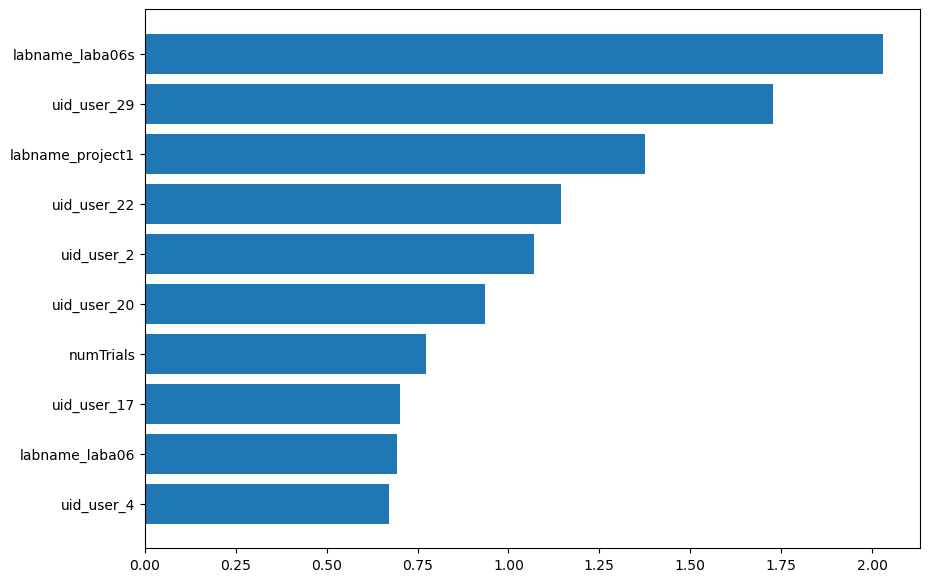

In [368]:
draw(coefs, X.columns, 10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

#### 1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 


In [369]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
dtc.fit(X, y)
pred = dtc.predict(X)
accuracy_score(y, pred)

0.5516014234875445

#### 2. Try different values of `max_depth`, calculate the accuracies.


In [370]:
max_acc = 0

for depth in range(1, 100):
    dtc = DecisionTreeClassifier(max_depth = depth, random_state=21)
    dtc.fit(X, y)
    pred = dtc.predict(X)
    acc = accuracy_score(y, pred)
    if acc > max_acc:
        max_acc = acc
        best_depth = depth
        
print(f'max_acc:{max_acc}, best_depth: {best_depth}')

max_acc:1.0, best_depth: 28


#### 3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function. 

In [371]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
dtc.fit(X, y)
pred = dtc.predict(X)
accuracy_score(y, pred)

0.5516014234875445

In [372]:
coefs = dtc.feature_importances_

In [373]:
coefs

array([0.14931603, 0.06154574, 0.        , 0.        , 0.        ,
       0.        , 0.09837711, 0.        , 0.06455791, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.07642063,
       0.        , 0.        , 0.        , 0.        , 0.01610628,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.06154768, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.05479407, 0.        , 0.08646791,
       0.        , 0.05629871, 0.27456793])

In [374]:
def draw(coefs, features, n):
    # coefs = coefs.mean(axis=0)
    coefs /= coefs.sum()
    indices = coefs.argsort()[::-1][:n]
    
    fig, ax = plt.subplots(figsize=(10,7))
    ax.barh(range(n), coefs[indices])
    ax.set_yticks(range(n))
    ax.set_yticklabels(features[indices])
    ax.invert_yaxis()

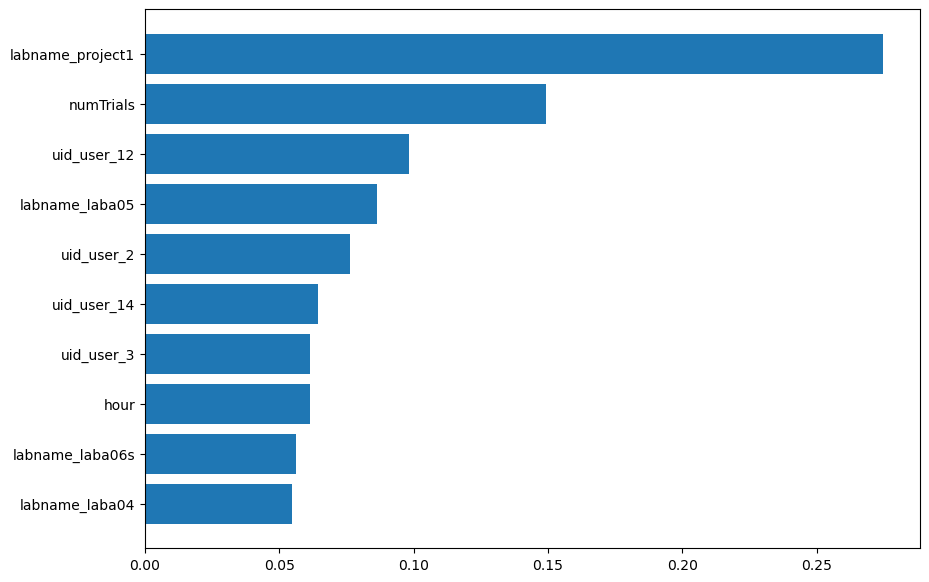

In [375]:
draw(coefs, X.columns, 10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

#### 1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 


In [376]:
rf = RandomForestClassifier(n_estimators=100, max_depth = 25, random_state=21)
rf.fit(X, y)
pred = rf.predict(X)
accuracy_score(y, pred)

1.0

#### 2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.

In [377]:
rf = RandomForestClassifier(n_estimators=10, max_depth = 25, random_state=21)
rf.fit(X, y)
pred = rf.predict(X)
accuracy_score(y, pred)

0.9958481613285883

In [378]:
rf = RandomForestClassifier(n_estimators=100, max_depth = 25, random_state=21)
rf.fit(X, y)
pred = rf.predict(X)
accuracy_score(y, pred)

1.0

In [379]:
rf = RandomForestClassifier(n_estimators=100, max_depth = 10, random_state=21)
rf.fit(X, y)
pred = rf.predict(X)
accuracy_score(y, pred)

0.8855278766310795

In [380]:
rf = RandomForestClassifier(n_estimators=100, max_depth = 15, random_state=21)
rf.fit(X, y)
pred = rf.predict(X)
accuracy_score(y, pred)

0.9780545670225386

#### 3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [381]:
rf = RandomForestClassifier(n_estimators=100, max_depth = 25, random_state=21)
rf.fit(X, y)
pred = rf.predict(X)
accuracy_score(y, pred)

1.0

In [382]:
coefs = rf.feature_importances_

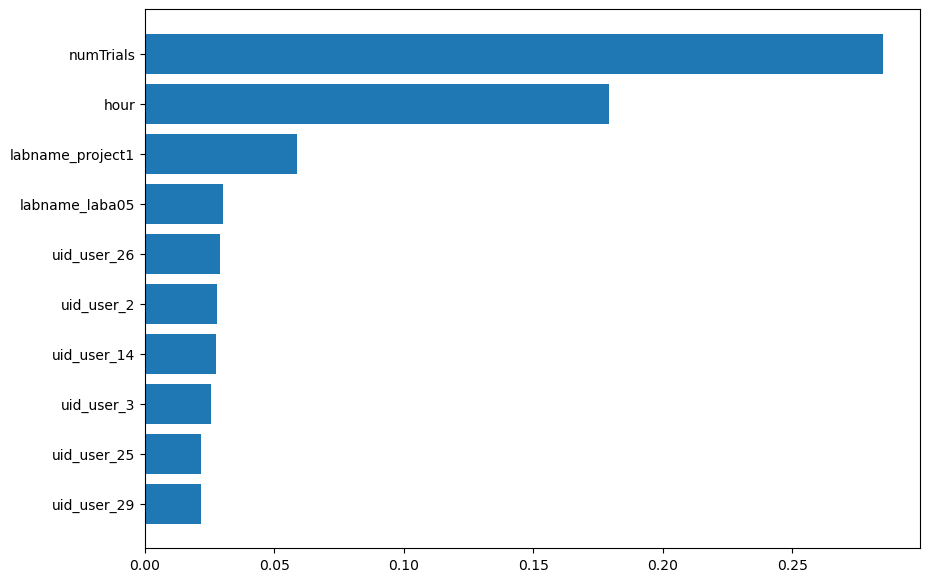

In [383]:
draw(coefs, X.columns, 10)